# 🚗 Prédiction de la consommation de carburant des véhicules
## Perceptron Multicouche (MLP) avec TensorFlow/Keras
---
# `Réalisé par: ` Mr Rachid ABOUOBAIDA
# `Encadré par: ` Mme Fatima GUEROUATE
# `Matière:     ` NLP et Computer vision
---

**Objectif :** Construire un réseau de neurones capable de prédire la consommation de carburant (en L/100km) à partir des caractéristiques techniques d'un véhicule.

**Dataset :** [EPA Fuel Economy Guide](https://www.fueleconomy.gov/feg/download.shtml) — données officielles du gouvernement américain sur **~46 000 véhicules** de 1984 à 2026, incluant :
- `year` : année du modèle (1984–2026)
- `cylinders` : nombre de cylindres
- `displ` : cylindrée en litres
- `drive` : type de traction (FWD, RWD, AWD)
- `VClass` : catégorie du véhicule (Car, SUV, Pickup, Van, Special)
- `tCharger` / `sCharger` : turbocompresseur / compresseur volumétrique
- `comb08` : consommation combinée en MPG **(variable cible)**

---

## Téléchargement du dataset

Le dataset **EPA Fuel Economy** est publié par le gouvernement américain.  
Il recense tous les véhicules homologués depuis **1984** (essence _et_ diesel), soit **~50 000 enregistrements** mis à jour chaque année.

> **Pourquoi ce dataset ?**
> - ~50 000 véhicules (essence + diesel), de 1984 à 2026
> - Inclut le type de transmission (`trany`) — Automatique, Manuelle, CVT
> - Inclut l'indicateur de turbo/compresseur (`tCharger`, `sCharger`)
> - Données officielles US, mises à jour annuellement

In [1]:
import os
import io
import urllib.request
import zipfile

os.makedirs('./data', exist_ok=True)

dest = './data/vehicles.csv'

if not os.path.exists(dest):
    print('Téléchargement du dataset EPA Fuel Economy...')
    url = 'https://www.fueleconomy.gov/feg/epadata/vehicles.csv.zip'
    with urllib.request.urlopen(url) as response:
        zip_data = response.read()
    with zipfile.ZipFile(io.BytesIO(zip_data)) as z:
        z.extract('vehicles.csv', './data/')
    print(f'✅ Dataset téléchargé — {os.path.getsize(dest) / 1024:.0f} KB')
else:
    print(f'✅ Dataset déjà présent ({os.path.getsize(dest) / 1024:.0f} KB)')

✅ Dataset déjà présent (21019 KB)


---
## 1. Importation des bibliothèques

On importe toutes les bibliothèques nécessaires au projet :
- **pandas / numpy** : manipulation des données
- **matplotlib / seaborn** : visualisation
- **TensorFlow / Keras** : construction et entraînement du réseau de neurones
- **scikit-learn** : prétraitement et métriques

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'   # Forcer TensorFlow à utiliser le CPU

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Configuration globale des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print(f'GPU disponibles    : {tf.config.list_physical_devices("GPU")}')

2026-03-25 20:32:43.534894: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.20.0
Keras version      : 3.13.2
GPU disponibles    : []


2026-03-25 20:32:51.062624: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-03-25 20:32:51.063496: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2026-03-25 20:32:51.063533: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2026-03-25 20:32:51.063558: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-03-25 20:32:51.063577: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: pc
2026-03-25 20:32:51.063589: I external/local_xla/xla/stream_executor/cuda/cuda_diagn

---
## 2. Chargement des données

Le fichier `auto-mpg.data` est un fichier texte séparé par des espaces. On définit manuellement les noms de colonnes, puis on charge les données avec pandas.

In [3]:
# Colonnes utiles du dataset EPA Fuel Economy
USECOLS = ['year', 'cylinders', 'displ', 'drive', 'VClass',
           'tCharger', 'sCharger', 'trany', 'fuelType1', 'comb08']

df = pd.read_csv('./data/vehicles.csv', usecols=USECOLS, low_memory=False)

# Garder uniquement les véhicules à combustion interne : essence + diesel
# (exclut électrique, hybride rechargeable, GPL, hydrogène…)
COMBUSTION = ['Regular Gasoline', 'Premium Gasoline', 'Midgrade Gasoline', 'Diesel']
df['is_diesel'] = (df['fuelType1'] == 'Diesel').astype(int)
df = df[df['fuelType1'].isin(COMBUSTION)].copy()
df = df.drop(columns=['fuelType1'])

print(f'Dimensions après filtre combustion : {df.shape}')
print(f'\nRépartition essence / diesel :')
print(f'  Essence : {(df["is_diesel"] == 0).sum():,} véhicules')
print(f'  Diesel  : {(df["is_diesel"] == 1).sum():,} véhicules')
df.head(10)

Dimensions après filtre combustion : (48298, 10)

Répartition essence / diesel :
  Essence : 46,988 véhicules
  Diesel  : 1,310 véhicules


,comb08,cylinders,displ,drive,trany,VClass,year,tCharger,sCharger,is_diesel
0,21,4.0,2.0,Rear-Wheel Drive,Manual 5-spd,Two Seaters,1985,NaN,NaN,0
1,11,12.0,4.9,Rear-Wheel Drive,Manual 5-spd,Two Seaters,1985,NaN,NaN,0
2,27,4.0,2.2,Front-Wheel Drive,Manual 5-spd,Subcompact Cars,1985,NaN,NaN,0
3,11,8.0,5.2,Rear-Wheel Drive,Automatic 3-spd,Vans,1985,NaN,NaN,0
4,19,4.0,2.2,4-Wheel or All-Wheel Drive,Manual 5-spd,Compact Cars,1993,T,NaN,0
5,22,4.0,1.8,Front-Wheel Drive,Automatic 3-spd,Compact Cars,1993,NaN,NaN,0
6,25,4.0,1.8,Front-Wheel Drive,Manual 5-spd,Compact Cars,1993,NaN,NaN,0
7,24,4.0,1.6,Front-Wheel Drive,Automatic 3-spd,Compact Cars,1993,NaN,NaN,0
8,26,4.0,1.6,Front-Wheel Drive,Manual 5-spd,Compact Cars,1993,NaN,NaN,0
9,25,4.0,1.8,Front-Wheel Drive,Automatic 4-spd,Compact Cars,1993,NaN,NaN,0


In [4]:
# Informations générales sur le dataset
print('=== Informations générales ===\n')
df.info()

print('\n=== Statistiques descriptives ===\n')
df.describe()

=== Informations générales ===

<class 'pandas.DataFrame'>
Index: 48298 entries, 0 to 49805
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   comb08     48298 non-null  int64  
 1   cylinders  48295 non-null  float64
 2   displ      48296 non-null  float64
 3   drive      47120 non-null  str    
 4   trany      48296 non-null  str    
 5   VClass     48298 non-null  str    
 6   year       48298 non-null  int64  
 7   tCharger   11517 non-null  str    
 8   sCharger   1143 non-null   str    
 9   is_diesel  48298 non-null  int64  
dtypes: float64(2), int64(3), str(5)
memory usage: 6.4 MB

=== Statistiques descriptives ===



,comb08,cylinders,displ,year,is_diesel
count,48298.000000,48295.000000,48296.000000,48298.000000,48298.000000
mean,20.714357,5.689864,3.262394,2004.750528,0.027123
std,5.618426,1.772703,1.348736,12.836122,0.162444
min,7.000000,2.000000,0.600000,1984.000000,0.000000
25%,17.000000,4.000000,2.100000,1993.000000,0.000000
50%,20.000000,6.000000,3.000000,2006.000000,0.000000
75%,24.000000,6.000000,4.200000,2016.000000,0.000000
max,59.000000,16.000000,8.400000,2026.000000,1.000000


---
## 3. Nettoyage des données

Avant toute modélisation, on vérifie et traite :
- Les **valeurs manquantes** (la colonne `horsepower` contient quelques `?`)
- Les **types de données** (conversion en numérique si nécessaire)
- Les colonnes non pertinentes (`car_name` est inutile pour la prédiction)

In [5]:
print('=== Valeurs manquantes par colonne ===\n')
print(df.isnull().sum())

print(f'\nLignes avec comb08 == 0 (invalide) : {(df["comb08"] == 0).sum()}')

=== Valeurs manquantes par colonne ===

comb08           0
cylinders        3
displ            2
drive         1178
trany            2
VClass           0
year             0
tCharger     36781
sCharger     47155
is_diesel        0
dtype: int64

Lignes avec comb08 == 0 (invalide) : 0


In [6]:
# 1. Supprimer les lignes avec cylindres, cylindrée, traction, transmission ou catégorie manquants
df = df.dropna(subset=['cylinders', 'displ', 'drive', 'VClass', 'trany'])

# 2. Supprimer les lignes avec comb08 = 0 (physiquement impossible)
df = df[df['comb08'] > 0]

# 3. Conversion des types
df['cylinders'] = df['cylinders'].astype(int)
df['year']      = df['year'].astype(int)
df['displ']     = df['displ'].astype(float)
df['comb08']    = df['comb08'].astype(float)
df['is_diesel'] = df['is_diesel'].astype(int)

print(f'Dimensions après nettoyage : {df.shape}')
print('\nValeurs manquantes restantes :')
print(df.isnull().sum())
df.head()

Dimensions après nettoyage : (47115, 10)

Valeurs manquantes restantes :
comb08           0
cylinders        0
displ            0
drive            0
trany            0
VClass           0
year             0
tCharger     35719
sCharger     45972
is_diesel        0
dtype: int64


,comb08,cylinders,displ,drive,trany,VClass,year,tCharger,sCharger,is_diesel
0,21.0,4,2.0,Rear-Wheel Drive,Manual 5-spd,Two Seaters,1985,NaN,NaN,0
1,11.0,12,4.9,Rear-Wheel Drive,Manual 5-spd,Two Seaters,1985,NaN,NaN,0
2,27.0,4,2.2,Front-Wheel Drive,Manual 5-spd,Subcompact Cars,1985,NaN,NaN,0
3,11.0,8,5.2,Rear-Wheel Drive,Automatic 3-spd,Vans,1985,NaN,NaN,0
4,19.0,4,2.2,4-Wheel or All-Wheel Drive,Manual 5-spd,Compact Cars,1993,T,NaN,0


---
## 4.  Prétraitement des données

### 4.1 Conversion MPG → L/100km
$$\text{L/100km} = \frac{235.214}{\text{MPG combiné}}$$

### 4.2 Encodage des variables catégorielles

| Variable | Modalités brutes | Regroupement |
|----------|-----------------|--------------|
| `drive`  | 7 valeurs | → 3 groupes : **FWD**, **RWD**, **AWD** |
| `VClass` | 33 valeurs | → 5 groupes : **Car**, **SUV**, **Pickup**, **Van**, **Special** |
| `trany`  | ~60 valeurs | → 3 groupes : **Automatic**, **CVT**, **Manual** |
| `tCharger`/`sCharger` | T / S / NaN | → 1 binaire : **forced_induction** |
| `is_diesel` | 0 / 1 | binaire déjà encodé |

### 4.3 Normalisation
`StandardScaler` centré-réduit, fitté uniquement sur le train set (évite le *data leakage*).

### Récapitulatif des features (16 au total)
```
year, cylinders, displ, forced_induction, is_diesel          (5 numériques)
drive_AWD, drive_FWD, drive_RWD                               (3 one-hot)
VClass_Car, VClass_Pickup, VClass_Special, VClass_SUV, VClass_Van  (5 one-hot)
tranny_Automatic, tranny_CVT, tranny_Manual                   (3 one-hot)
```

In [7]:
# --- 4.1 Conversion de la variable cible ---
df['L100km'] = 235.214 / df['comb08']
df = df.drop(columns=['comb08'])

print('Distribution de la consommation en L/100km :')
print(df['L100km'].describe())

Distribution de la consommation en L/100km :
count    47115.000000
mean        12.153893
std          3.135573
min          3.986678
25%         10.226696
50%         11.760700
75%         13.836118
max         33.602000
Name: L100km, dtype: float64


In [8]:
# --- 4.2 Encodage des variables catégorielles ---

# A) Regroupement de 'drive' en 3 catégories
DRIVE_MAP = {
    'Front-Wheel Drive':           'FWD',
    '2-Wheel Drive':               'FWD',
    'Rear-Wheel Drive':            'RWD',
    'All-Wheel Drive':             'AWD',
    '4-Wheel Drive':               'AWD',
    '4-Wheel or All-Wheel Drive':  'AWD',
    'Part-time 4-Wheel Drive':     'AWD',
}
df['drive'] = df['drive'].map(DRIVE_MAP).fillna('FWD')

# B) Regroupement de 'VClass' en 5 catégories
def map_vclass(v: str) -> str:
    v = str(v).lower()
    if 'suv' in v or 'sport utility' in v:
        return 'SUV'
    if 'pickup' in v:
        return 'Pickup'
    if 'van' in v or 'minivan' in v:
        return 'Van'
    if 'special' in v:
        return 'Special'
    return 'Car'

df['VClass'] = df['VClass'].apply(map_vclass)

# C) Indicateur de suralimentation (turbocompresseur ou compresseur volumétrique)
df['forced_induction'] = ((df['tCharger'] == 'T') | (df['sCharger'] == 'S')).astype(int)
df = df.drop(columns=['tCharger', 'sCharger'])

# D) Type de transmission : Automatic / CVT / Manual
def map_transmission(t: str) -> str:
    t = str(t).upper()
    if 'CVT' in t or ('AV' in t and 'VARIABLE' in t) or 'CONTINUOUSLY' in t:
        return 'CVT'
    if t.startswith('M') or 'MANUAL' in t:
        return 'Manual'
    return 'Automatic'   # A, AM, AS, AMT, etc.

df['tranny'] = df['trany'].apply(map_transmission)
df = df.drop(columns=['trany'])

print('Distribution drive    :', df['drive'].value_counts().to_dict())
print('Distribution VClass   :', df['VClass'].value_counts().to_dict())
print('Distribution tranny   :', df['tranny'].value_counts().to_dict())
print('Forced induction       :', df['forced_induction'].value_counts().to_dict())
print('Is diesel              :', df['is_diesel'].value_counts().to_dict())

# E) One-hot encoding
df = pd.get_dummies(df, columns=['drive', 'VClass', 'tranny'], drop_first=False, dtype=float)

print('\nColonnes après encodage :', df.columns.tolist())
df.head()

Distribution drive    : {'FWD': 16084, 'AWD': 15596, 'RWD': 15435}
Distribution VClass   : {'Car': 26413, 'SUV': 8999, 'Pickup': 6799, 'Special': 2546, 'Van': 2358}
Distribution tranny   : {'Automatic': 34322, 'Manual': 12793}
Forced induction       : {0: 34785, 1: 12330}
Is diesel              : {0: 45962, 1: 1153}

Colonnes après encodage : ['cylinders', 'displ', 'year', 'is_diesel', 'L100km', 'forced_induction', 'drive_AWD', 'drive_FWD', 'drive_RWD', 'VClass_Car', 'VClass_Pickup', 'VClass_SUV', 'VClass_Special', 'VClass_Van', 'tranny_Automatic', 'tranny_Manual']


,cylinders,displ,year,is_diesel,L100km,forced_induction,drive_AWD,drive_FWD,drive_RWD,VClass_Car,VClass_Pickup,VClass_SUV,VClass_Special,VClass_Van,tranny_Automatic,tranny_Manual
0,4,2.0,1985,0,11.200667,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,12,4.9,1985,0,21.383091,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,4,2.2,1985,0,8.711630,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,8,5.2,1985,0,21.383091,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,4,2.2,1993,0,12.379684,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [9]:
# --- 4.3 Séparation features / cible ---
TARGET   = 'L100km'
FEATURES = [col for col in df.columns if col != TARGET]

X = df[FEATURES].values
y = df[TARGET].values

print(f'Features ({len(FEATURES)}) : {FEATURES}')
print(f'Shape X : {X.shape}, Shape y : {y.shape}')

Features (15) : ['cylinders', 'displ', 'year', 'is_diesel', 'forced_induction', 'drive_AWD', 'drive_FWD', 'drive_RWD', 'VClass_Car', 'VClass_Pickup', 'VClass_SUV', 'VClass_Special', 'VClass_Van', 'tranny_Automatic', 'tranny_Manual']
Shape X : (47115, 15), Shape y : (47115,)


In [10]:
# --- Division Train / Test (80 / 20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Entraînement : {X_train.shape[0]} exemples')
print(f'Test         : {X_test.shape[0]} exemples')

# --- Normalisation (fit sur train uniquement — évite le data leakage) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\n✅ Normalisation appliquée (StandardScaler)')
print(f'Moyenne train (après norm) ≈ {X_train_scaled.mean():.4f}')
print(f'Écart-type train (après norm) ≈ {X_train_scaled.std():.4f}')

Entraînement : 37692 exemples
Test         : 9423 exemples

✅ Normalisation appliquée (StandardScaler)
Moyenne train (après norm) ≈ -0.0000
Écart-type train (après norm) ≈ 1.0000


---
## 5. Analyse Exploratoire des Données (EDA)

Avant de modéliser, on analyse visuellement la distribution des variables et leurs relations avec la variable cible.

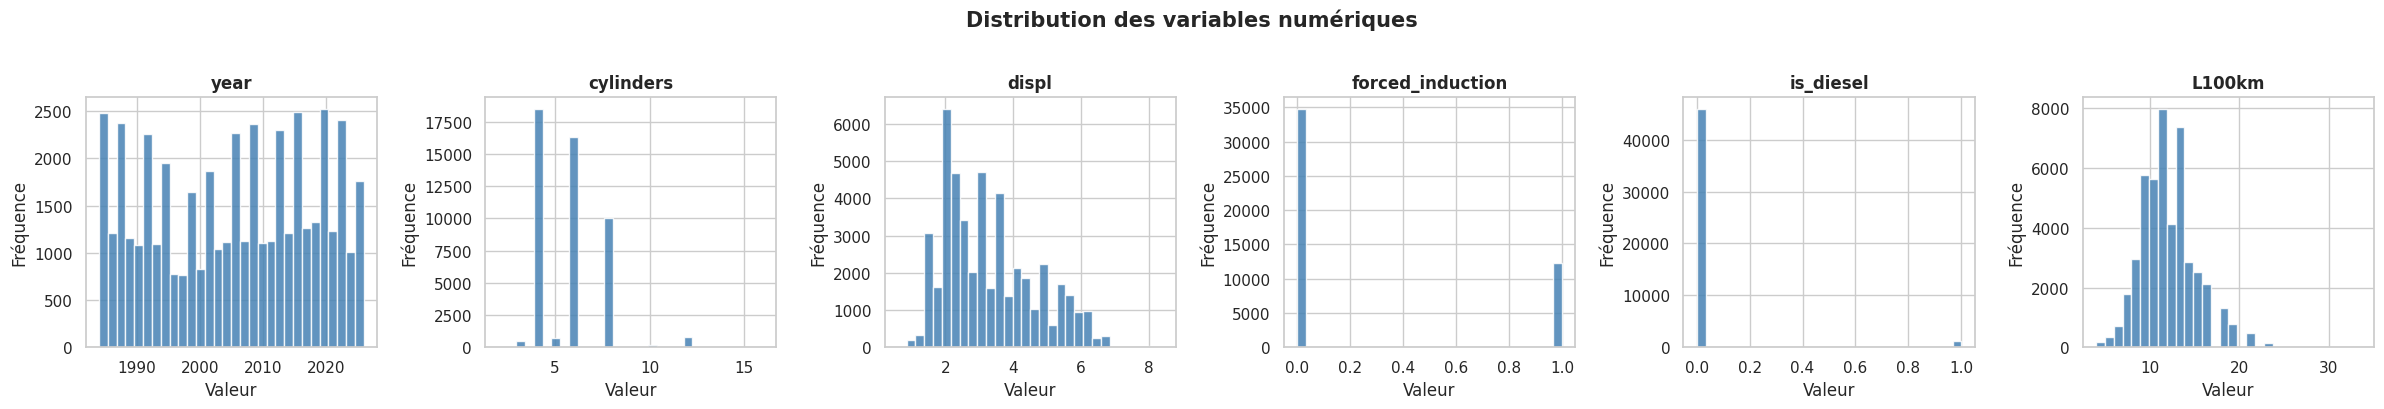

In [11]:
# --- 5.1 Distribution des variables numériques continues ---
numeric_cols = ['year', 'cylinders', 'displ', 'forced_induction', 'is_diesel', 'L100km']

fig, axes = plt.subplots(1, 6, figsize=(24, 4))

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')

plt.suptitle('Distribution des variables numériques', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./data/distributions.png', dpi=120, bbox_inches='tight')
plt.show()

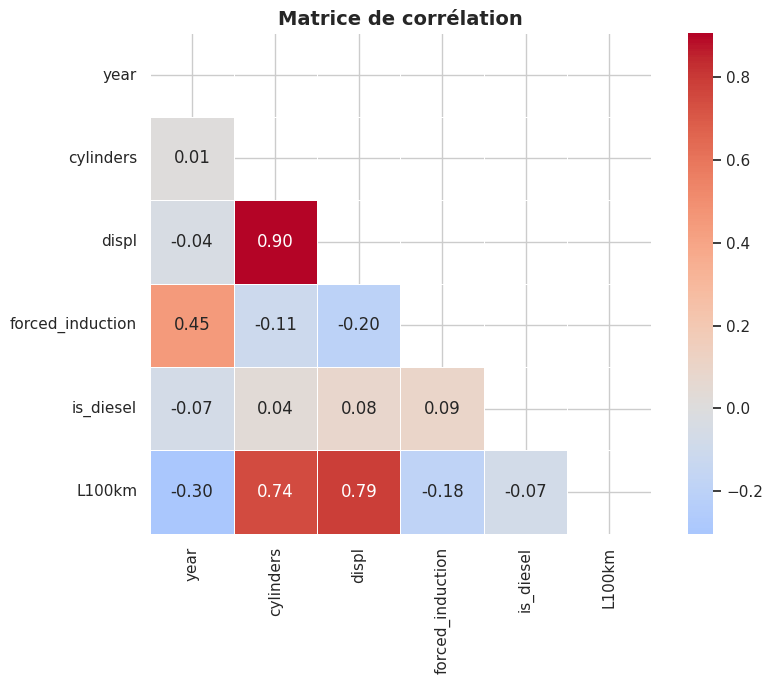


Corrélations avec L/100km (variable cible) :
L100km              1.000000
displ               0.787225
cylinders           0.744752
is_diesel          -0.072835
forced_induction   -0.184633
year               -0.302194
Name: L100km, dtype: float64


In [12]:
# --- 5.2 Matrice de corrélation (variables numériques continues) ---
corr_cols = ['year', 'cylinders', 'displ', 'forced_induction', 'is_diesel', 'L100km']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Matrice de corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nCorrélations avec L/100km (variable cible) :')
print(corr_matrix['L100km'].sort_values(ascending=False))

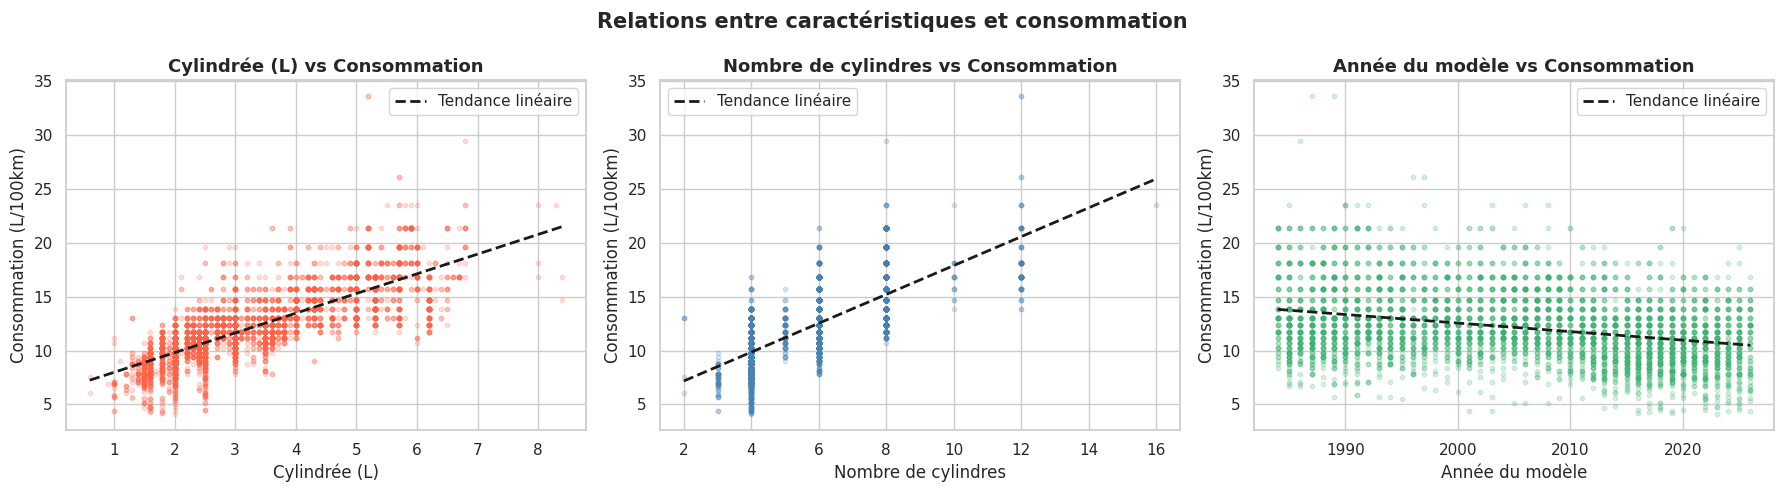

In [13]:
# --- 5.3 Caractéristiques clés vs Consommation ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_pairs = [
    ('displ',    'Cylindrée (L)',        'tomato'),
    ('cylinders','Nombre de cylindres',  'steelblue'),
    ('year',     'Année du modèle',      'mediumseagreen'),
]

for ax, (feat, label, color) in zip(axes, scatter_pairs):
    # Sous-échantillon pour la lisibilité (5 000 points)
    sample = df.sample(n=min(5000, len(df)), random_state=42)
    ax.scatter(sample[feat], sample['L100km'], alpha=0.2, color=color, s=10)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Consommation (L/100km)', fontsize=12)
    ax.set_title(f'{label} vs Consommation', fontsize=13, fontweight='bold')
    z = np.polyfit(sample[feat], sample['L100km'], 1)
    p = np.poly1d(z)
    xl = np.linspace(sample[feat].min(), sample[feat].max(), 200)
    ax.plot(xl, p(xl), 'k--', linewidth=2, label='Tendance linéaire')
    ax.legend()

plt.suptitle('Relations entre caractéristiques et consommation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/scatter_plots.png', dpi=120, bbox_inches='tight')
plt.show()

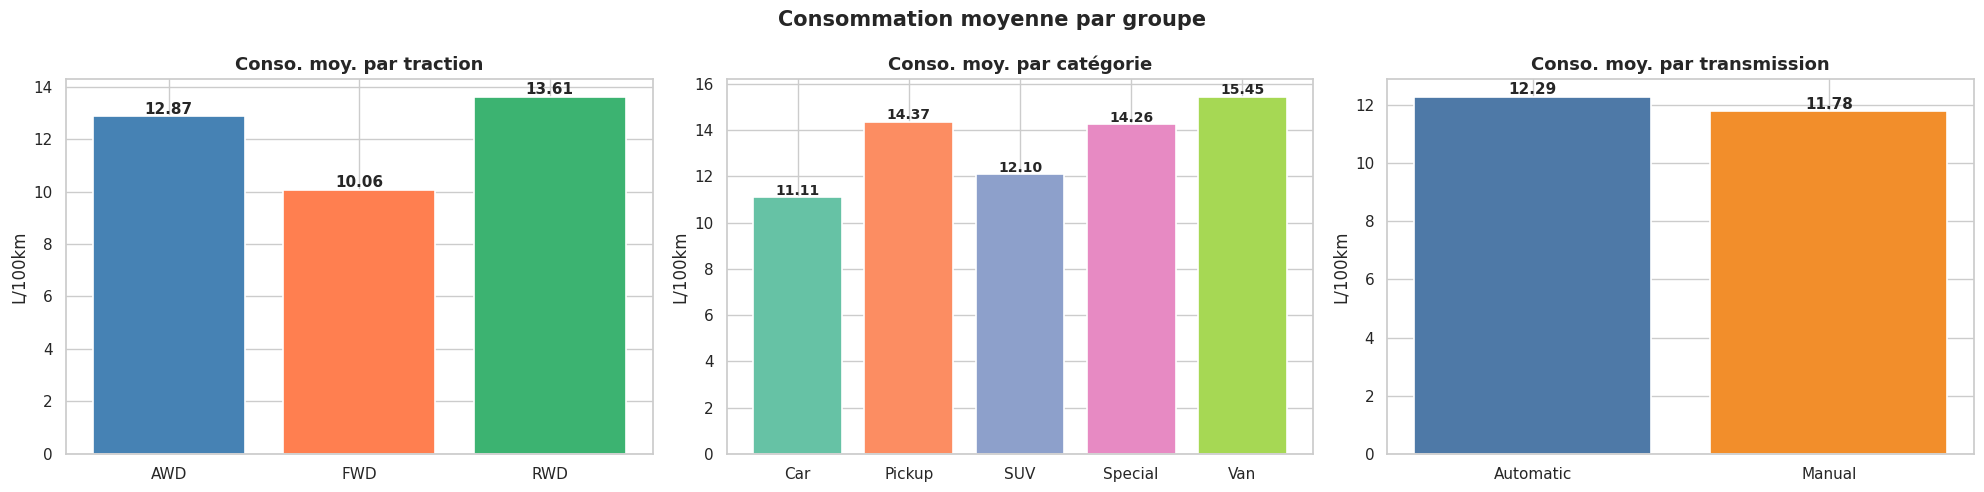

In [14]:
# --- 5.4 Consommation moyenne par type de traction, catégorie et transmission ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Par type de traction
drive_cols  = [c for c in df.columns if c.startswith('drive_')]
drive_means = {c.replace('drive_', ''): df.loc[df[c] == 1.0, 'L100km'].mean() for c in drive_cols}
axes[0].bar(drive_means.keys(), drive_means.values(),
            color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Conso. moy. par traction', fontsize=13, fontweight='bold')
axes[0].set_ylabel('L/100km')
for i, (k, v) in enumerate(drive_means.items()):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

# Par catégorie de véhicule
vclass_cols  = [c for c in df.columns if c.startswith('VClass_')]
vclass_means = {c.replace('VClass_', ''): df.loc[df[c] == 1.0, 'L100km'].mean() for c in vclass_cols}
axes[1].bar(vclass_means.keys(), vclass_means.values(),
            color=plt.cm.Set2.colors[:len(vclass_means)], edgecolor='white', linewidth=1.2)
axes[1].set_title('Conso. moy. par catégorie', fontsize=13, fontweight='bold')
axes[1].set_ylabel('L/100km')
for i, (k, v) in enumerate(vclass_means.items()):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# Par type de transmission
tranny_cols  = [c for c in df.columns if c.startswith('tranny_')]
tranny_means = {c.replace('tranny_', ''): df.loc[df[c] == 1.0, 'L100km'].mean() for c in tranny_cols}
axes[2].bar(tranny_means.keys(), tranny_means.values(),
            color=['#4e79a7', '#f28e2b', '#59a14f'], edgecolor='white', linewidth=1.2)
axes[2].set_title('Conso. moy. par transmission', fontsize=13, fontweight='bold')
axes[2].set_ylabel('L/100km')
for i, (k, v) in enumerate(tranny_means.items()):
    axes[2].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Consommation moyenne par groupe', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/consumption_by_origin.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Modélisation — Perceptron Multicouche (MLP)

### Architecture du réseau

On construit un réseau `Sequential` avec :
- **Couche d'entrée** : taille = nombre de features
- **Couche cachée 1** : 64 neurones, activation ReLU, + Dropout(0.1)
- **Couche cachée 2** : 32 neurones, activation ReLU
- **Couche de sortie** : 1 neurone, activation linéaire (régression)

```
Input (n_features)
    ↓
Dense(64, relu) → Dropout(0.1)
    ↓
Dense(32, relu)
    ↓
Dense(1)  ← sortie continue
```

### Compilation
- **Optimizer** : Adam (adaptatif, performant sur ce type de données)
- **Loss** : MSE (Mean Squared Error) — standard pour la régression
- **Metric** : MAE (Mean Absolute Error) — interprétable en L/100km

In [15]:
n_features = X_train_scaled.shape[1]

def build_mlp(n_features: int) -> keras.Model:
    """Construit et compile le modèle MLP."""
    model = keras.Sequential(
        [
            layers.Input(shape=(n_features,), name='input'),
            layers.Dense(64, activation='relu', name='dense_1'),
            layers.Dropout(0.1, name='dropout_1'),
            layers.Dense(32, activation='relu', name='dense_2'),
            layers.Dense(1, name='output'),
        ],
        name='MLP_Consommation'
    )
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_mlp(n_features)
model.summary()

Model: "MLP_Consommation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

---
## 7. Entraînement du modèle

On entraîne le modèle pendant au maximum **150 epochs** avec un **EarlyStopping** :
- **patience = 20** : arrêt si la validation loss ne s'améliore pas pendant 20 epochs
- **restore_best_weights = True** : on récupère les meilleurs poids automatiquement

On utilise **20 % des données d'entraînement** comme ensemble de validation.

In [16]:
# Callback EarlyStopping (Bonus)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Entraînement
history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print(f'\n✅ Entraînement terminé après {len(history.history["loss"])} epochs.')

Epoch 1/150
943/943 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9.1270 - mae: 1.8566 - val_loss: 1.8526 - val_mae: 0.9799
Epoch 2/150
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 2.3553 - mae: 1.1403 - val_loss: 1.7572 - val_mae: 0.9492
Epoch 3/150
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 2.2069 - mae: 1.1007 - val_loss: 1.7031 - val_mae: 0.9393
Epoch 4/150
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 2.0783 - mae: 1.0640 - val_loss: 1.6250 - val_mae: 0.9071
Epoch 5/150
943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 1.9626 - mae: 1.0266 - val_loss: 1.6081 - val_mae: 0.9049
Epoch 6/150
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 1.8449 - mae: 0.9946 - val_loss: 1.5620 - val_mae: 0.8827
Epoch 7/150
943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 1.7634 - mae: 0.9659 - val_loss: 1.5277 - val_mae: 0.8787
Epoch 8/150
943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 1.7134 - mae: 0.9464 - val_loss: 1.5150 - val_mae: 0.8723
Epoch 9/150
943/943 ━━━━━━━━━━━━━━━━━━

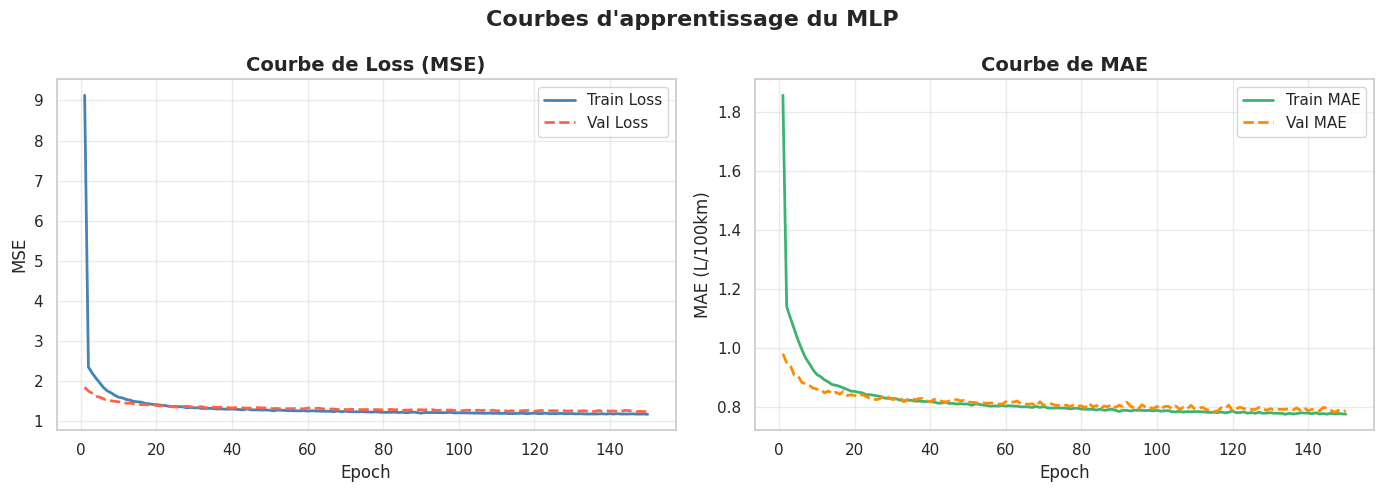

In [17]:
# --- Courbes d'apprentissage ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['loss']) + 1)

# Loss (MSE)
axes[0].plot(epochs_range, history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'], label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Courbe de Loss (MSE)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.4)

# MAE
axes[1].plot(epochs_range, history.history['mae'],     label='Train MAE', color='mediumseagreen', linewidth=2)
axes[1].plot(epochs_range, history.history['val_mae'], label='Val MAE',   color='darkorange',    linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (L/100km)')
axes[1].set_title('Courbe de MAE', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle("Courbes d'apprentissage du MLP", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Évaluation sur le jeu de test

On évalue le modèle entraîné sur les données de test (jamais vues pendant l'entraînement) et on calcule :
- **MSE** : erreur quadratique moyenne
- **RMSE** : racine de MSE (même unité que la cible)
- **MAE** : erreur absolue moyenne
- **R²** : coefficient de détermination (1 = parfait)

In [18]:
# Évaluation Keras
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_mlp = model.predict(X_test_scaled, verbose=0).flatten()

# Métriques scikit-learn
mse_mlp  = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
mae_mlp  = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp   = r2_score(y_test, y_pred_mlp)

print('=== Résultats MLP (jeu de test) ===')
print(f'  MSE  : {mse_mlp:.4f}')
print(f'  RMSE : {rmse_mlp:.4f} L/100km')
print(f'  MAE  : {mae_mlp:.4f} L/100km')
print(f'  R²   : {r2_mlp:.4f}')

=== Résultats MLP (jeu de test) ===
  MSE  : 1.2081
  RMSE : 1.0991 L/100km
  MAE  : 0.7670 L/100km
  R²   : 0.8796


### 🔁 Bonus — Comparaison avec une Régression Linéaire

On entraîne une régression linéaire classique (même split) pour comparer les performances avec le MLP.

In [19]:
# Entraînement régression linéaire
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('=== Comparaison des modèles ===')
print(f'\n{"Métrique":<12} {"MLP":>12} {"Régression Lin.":>18}')
print('-' * 44)
print(f'{"MSE":<12} {mse_mlp:>12.4f} {mse_lr:>18.4f}')
print(f'{"RMSE":<12} {rmse_mlp:>12.4f} {rmse_lr:>18.4f}')
print(f'{"MAE":<12} {mae_mlp:>12.4f} {mae_lr:>18.4f}')
print(f'{"R²":<12} {r2_mlp:>12.4f} {r2_lr:>18.4f}')

# Tableau de comparaison
comparison_df = pd.DataFrame({
    'Métrique': ['MSE', 'RMSE', 'MAE', 'R²'],
    'MLP':              [mse_mlp, rmse_mlp, mae_mlp, r2_mlp],
    'Régression Linéaire': [mse_lr, rmse_lr, mae_lr, r2_lr]
})
comparison_df.set_index('Métrique').round(4)

=== Comparaison des modèles ===

Métrique              MLP    Régression Lin.
--------------------------------------------
MSE                1.2081             1.9826
RMSE               1.0991             1.4081
MAE                0.7670             1.0089
R²                 0.8796             0.8024


,MLP,Régression Linéaire
Métrique,,
MSE,1.2081,1.9826
RMSE,1.0991,1.4081
MAE,0.7670,1.0089
R²,0.8796,0.8024


---
## 9. Visualisation des prédictions

On compare graphiquement les **valeurs réelles** et les **prédictions** du MLP pour évaluer visuellement la qualité du modèle.

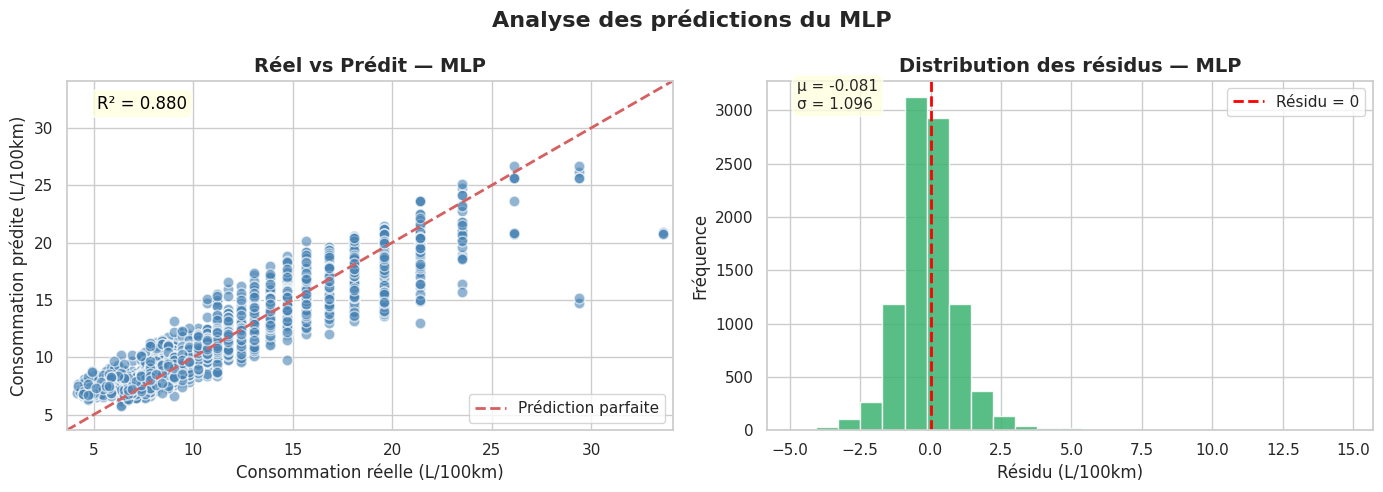

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Valeurs réelles vs Prédictions (scatter) ---
vmin = min(y_test.min(), y_pred_mlp.min()) - 0.5
vmax = max(y_test.max(), y_pred_mlp.max()) + 0.5

axes[0].scatter(y_test, y_pred_mlp, alpha=0.6, color='steelblue', edgecolors='white', s=60)
axes[0].plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Consommation réelle (L/100km)', fontsize=12)
axes[0].set_ylabel('Consommation prédite (L/100km)', fontsize=12)
axes[0].set_title('Réel vs Prédit — MLP', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(vmin, vmax)
axes[0].set_ylim(vmin, vmax)
axes[0].text(0.05, 0.92, f'R² = {r2_mlp:.3f}', transform=axes[0].transAxes,
             fontsize=12, color='black',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Graphique 2 : Distribution des résidus ---
residuals = y_test - y_pred_mlp
axes[1].hist(residuals, bins=25, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Résidu = 0')
axes[1].set_xlabel('Résidu (L/100km)', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title('Distribution des résidus — MLP', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].text(0.05, 0.92, f'μ = {residuals.mean():.3f}\nσ = {residuals.std():.3f}',
             transform=axes[1].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Analyse des prédictions du MLP', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/predictions_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

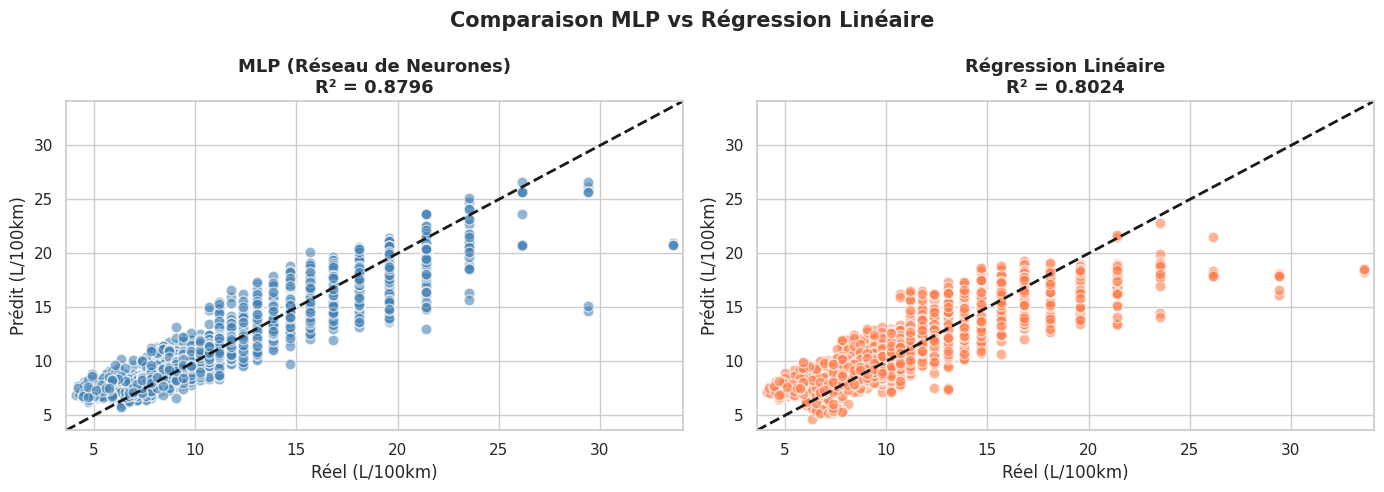

In [21]:
# --- Comparaison MLP vs Régression Linéaire (scatter) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, label, color in zip(
    axes,
    [y_pred_mlp, y_pred_lr],
    ['MLP (Réseau de Neurones)', 'Régression Linéaire'],
    ['steelblue', 'coral']
):
    ax.scatter(y_test, y_pred, alpha=0.6, color=color, edgecolors='white', s=60)
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', linewidth=2)
    ax.set_xlabel('Réel (L/100km)')
    ax.set_ylabel('Prédit (L/100km)')
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{label}\nR² = {r2:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

plt.suptitle('Comparaison MLP vs Régression Linéaire', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 10. Tests personnalisés — Prédiction interactive

Entrez les caractéristiques d'un véhicule pour prédire sa consommation.

**Valeurs typiques de référence :**
| Variable       | Petite voiture | Voiture moyenne | Grosse voiture |
|----------------|:--------------:|:---------------:|:--------------:|
| cylinders      | 4              | 6               | 8              |
| displacement   | 100 in³        | 200 in³         | 350 in³        |
| horsepower     | 75 cv          | 120 cv          | 180 cv         |
| weight         | 2000 lbs       | 3000 lbs        | 4000 lbs       |
| acceleration   | 15 s           | 14 s            | 12 s           |
| model_year     | 70-82          | 70-82           | 70-82          |
| origin         | 1/2/3          | 1/2/3           | 1/2/3          |

In [22]:
def predict_consumption(
    year:             int,
    cylinders:        int,
    displ:            float,
    drive:            str,   # 'FWD', 'RWD' ou 'AWD'
    vclass:           str,   # 'Car', 'SUV', 'Pickup', 'Van', 'Special'
    tranny:           str,   # 'Automatic', 'CVT' ou 'Manual'
    forced_induction: int,   # 0 = atmosphérique, 1 = turbo/compresseur
    is_diesel:        int,   # 0 = essence, 1 = diesel
) -> float:
    """
    Prédit la consommation de carburant (L/100km).

    Paramètres
    ----------
    year             : année du modèle (ex: 2024)
    cylinders        : nombre de cylindres (ex: 4)
    displ            : cylindrée en litres (ex: 2.0)
    drive            : type de traction — 'FWD', 'RWD' ou 'AWD'
    vclass           : catégorie — 'Car', 'SUV', 'Pickup', 'Van', 'Special'
    tranny           : transmission — 'Automatic', 'CVT' ou 'Manual'
    forced_induction : 1 = turbocompresseur ou compresseur, 0 = atmosphérique
    is_diesel        : 1 = diesel, 0 = essence
    """
    feature_lookup = {
        'year':               float(year),
        'cylinders':          float(cylinders),
        'displ':              float(displ),
        'forced_induction':   float(forced_induction),
        'is_diesel':          float(is_diesel),
        'drive_AWD':          1.0 if drive   == 'AWD'       else 0.0,
        'drive_FWD':          1.0 if drive   == 'FWD'       else 0.0,
        'drive_RWD':          1.0 if drive   == 'RWD'       else 0.0,
        'VClass_Car':         1.0 if vclass  == 'Car'       else 0.0,
        'VClass_Pickup':      1.0 if vclass  == 'Pickup'    else 0.0,
        'VClass_Special':     1.0 if vclass  == 'Special'   else 0.0,
        'VClass_SUV':         1.0 if vclass  == 'SUV'       else 0.0,
        'VClass_Van':         1.0 if vclass  == 'Van'       else 0.0,
        'tranny_Automatic':   1.0 if tranny  == 'Automatic' else 0.0,
        'tranny_CVT':         1.0 if tranny  == 'CVT'       else 0.0,
        'tranny_Manual':      1.0 if tranny  == 'Manual'    else 0.0,
    }

    feature_vector = np.array([[feature_lookup.get(f, 0.0) for f in FEATURES]])
    feature_scaled = scaler.transform(feature_vector)
    prediction     = float(model.predict(feature_scaled, verbose=0)[0][0])
    return max(0.1, prediction)


# ── Exemples de prédiction ───────────────────────────────────────────────────
print('=' * 70)
print('           PRÉDICTION DE CONSOMMATION DE CARBURANT')
print('=' * 70)

exemples = [
    dict(year=2024, cylinders=3, displ=1.0, drive='FWD', vclass='Car',
         tranny='CVT', forced_induction=1, is_diesel=0,
         label='Mini citadine 3 cyl. turbo CVT (2024, 1.0L, FWD)'),
    dict(year=2023, cylinders=4, displ=1.5, drive='FWD', vclass='Car',
         tranny='Automatic', forced_induction=1, is_diesel=0,
         label='Citadine turbo 4L auto (2023, 1.5L, FWD)'),
    dict(year=2022, cylinders=6, displ=3.0, drive='RWD', vclass='Car',
         tranny='Automatic', forced_induction=0, is_diesel=0,
         label='Berline V6 (2022, 3.0L, RWD, auto)'),
    dict(year=2020, cylinders=8, displ=5.0, drive='AWD', vclass='Pickup',
         tranny='Automatic', forced_induction=0, is_diesel=0,
         label='Pickup V8 essence (2020, 5.0L, AWD)'),
    dict(year=2022, cylinders=6, displ=3.0, drive='AWD', vclass='Pickup',
         tranny='Automatic', forced_induction=0, is_diesel=1,
         label='Pickup diesel V6 (2022, 3.0L, AWD)'),
    dict(year=2021, cylinders=4, displ=2.0, drive='AWD', vclass='SUV',
         tranny='Automatic', forced_induction=1, is_diesel=0,
         label='SUV turbo compact (2021, 2.0L, AWD)'),
    dict(year=2015, cylinders=6, displ=3.5, drive='FWD', vclass='Van',
         tranny='Automatic', forced_induction=0, is_diesel=0,
         label='Minivan V6 (2015, 3.5L, FWD)'),
    dict(year=2023, cylinders=4, displ=2.0, drive='FWD', vclass='Car',
         tranny='Manual', forced_induction=0, is_diesel=0,
         label='Berline 4L manuelle (2023, 2.0L, FWD)'),
]

for ex in exemples:
    label = ex.pop('label')
    conso = predict_consumption(**ex)
    mpg   = round(235.214 / conso, 1)
    print(f'\n🚗 {label}')
    print(f'   → Consommation : {conso:.2f} L/100km  ({mpg} MPG)')

print('\n' + '=' * 70)

           PRÉDICTION DE CONSOMMATION DE CARBURANT

🚗 Mini citadine 3 cyl. turbo CVT (2024, 1.0L, FWD)
   → Consommation : 7.04 L/100km  (33.4 MPG)

🚗 Citadine turbo 4L auto (2023, 1.5L, FWD)
   → Consommation : 7.73 L/100km  (30.4 MPG)

🚗 Berline V6 (2022, 3.0L, RWD, auto)
   → Consommation : 9.18 L/100km  (25.6 MPG)

🚗 Pickup V8 essence (2020, 5.0L, AWD)
   → Consommation : 13.65 L/100km  (17.2 MPG)

🚗 Pickup diesel V6 (2022, 3.0L, AWD)
   → Consommation : 10.59 L/100km  (22.2 MPG)

🚗 SUV turbo compact (2021, 2.0L, AWD)
   → Consommation : 10.09 L/100km  (23.3 MPG)

🚗 Minivan V6 (2015, 3.5L, FWD)
   → Consommation : 11.37 L/100km  (20.7 MPG)

🚗 Berline 4L manuelle (2023, 2.0L, FWD)
   → Consommation : 8.49 L/100km  (27.7 MPG)



In [23]:
# ══════════════════════════════════════════════════════════════════
# 🖊️  Modifiez ces valeurs pour tester votre propre véhicule
# ══════════════════════════════════════════════════════════════════

mon_vehicule = dict(
    year             = 2024,          # Année du modèle
    cylinders        = 4,             # Nombre de cylindres
    displ            = 2.0,           # Cylindrée en litres
    drive            = 'FWD',         # 'FWD', 'RWD' ou 'AWD'
    vclass           = 'Car',         # 'Car', 'SUV', 'Pickup', 'Van', 'Special'
    tranny           = 'Automatic',   # 'Automatic', 'CVT' ou 'Manual'
    forced_induction = 0,             # 1 = turbo/compresseur, 0 = atmosphérique
    is_diesel        = 0,             # 1 = diesel, 0 = essence
)

conso_predite = predict_consumption(**mon_vehicule)
mpg_predit    = round(235.214 / conso_predite, 1)

print('🚗 Mon véhicule :')
for k, v in mon_vehicule.items():
    print(f'   {k:<20} : {v}')
print(f'\n⛽ Consommation prédite : {conso_predite:.2f} L/100km  ({mpg_predit} MPG)')

🚗 Mon véhicule :
   year                 : 2024
   cylinders            : 4
   displ                : 2.0
   drive                : FWD
   vclass               : Car
   tranny               : Automatic
   forced_induction     : 0
   is_diesel            : 0

⛽ Consommation prédite : 6.80 L/100km  (34.6 MPG)


---
## 11. Sauvegarde du modèle

On sauvegarde :
1. Le **modèle Keras** complet (architecture + poids) au format `.keras` (recommandé en TF 2.x)
2. Le **scaler** (indispensable pour reproduire les prédictions) via `joblib`
3. La **liste des features** pour éviter toute ambiguïté lors du rechargement

In [24]:
import joblib
import json

os.makedirs('./models', exist_ok=True)

# 1. Sauvegarde du modèle Keras
model_path = './models/mlp_consommation.keras'
model.save(model_path)
print(f'✅ Modèle sauvegardé : {model_path}')

# 2. Sauvegarde du scaler
scaler_path = './models/scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f'✅ Scaler sauvegardé : {scaler_path}')

# 3. Sauvegarde de la liste des features
features_path = './models/features.json'
with open(features_path, 'w') as f:
    json.dump(FEATURES, f, indent=2)
print(f'✅ Features sauvegardées : {features_path}')

# Afficher la taille du fichier modèle
size_kb = os.path.getsize(model_path) / 1024
print(f'\n📦 Taille du modèle : {size_kb:.1f} KB')

✅ Modèle sauvegardé : ./models/mlp_consommation.keras
✅ Scaler sauvegardé : ./models/scaler.joblib
✅ Features sauvegardées : ./models/features.json

📦 Taille du modèle : 63.8 KB


In [25]:
# --- Vérification : rechargement et test ---
loaded_model  = keras.models.load_model('./models/mlp_consommation.keras')
loaded_scaler = joblib.load('./models/scaler.joblib')

# Test sur 3 exemples du jeu de test
X_sample = X_test_scaled[:3]
pred_original = model.predict(X_sample, verbose=0).flatten()
pred_loaded   = loaded_model.predict(X_sample, verbose=0).flatten()

print('=== Vérification du rechargement ===')
print(f'Prédictions originales : {pred_original.round(3)}')
print(f'Prédictions rechargées : {pred_loaded.round(3)}')
print(f'Différence max         : {np.abs(pred_original - pred_loaded).max():.6f}')
print('\n✅ Le modèle rechargé produit des résultats identiques.')

=== Vérification du rechargement ===
Prédictions originales : [13.242 14.123 11.799]
Prédictions rechargées : [13.242 14.123 11.799]
Différence max         : 0.000000

✅ Le modèle rechargé produit des résultats identiques.
